# SIOC 251 – Homework 2 Notebook

## Longwave Radiative Transfer and Weighting Functions 

**Name:** Amanda Mallinckrodt  
**Date:** 05/06/26

## Problem Statement


### Part I: Weighting Function

Assume a well-mixed gas with an extinction coefficient

$$
\beta_e(z) = C e^{-z/H}
$$

where \(C\) is a gas concentration coefficient and \(H\) is the scale height.

Using the above extinction coefficient, derive the following formulas:

1. Optical depths

    $$\tau(0,z)$$
    $$\tau(z,\infty)$$
    $$\tau^*$$

2. The flux transmittance from \(z\) to TOA

$$
t_F(z,\infty)
$$

3. The upwelling flux weighting function

$$
W_F^\uparrow(z)
$$

With

$$
C = f \times 1.25 \times 10^{-4}\ \mathrm{m}^{-1}
$$

where \(f\) is a scaling factor.









# TOA Outgoing Radiation Derivation r

Assume the extinction profile

$$
\beta_e(z)=Ce^{-z/H}
$$

where:

- \(C\) is the concentration coefficient
- \(H\) is the atmospheric scale height

Using the diffusivity approximation in place of $\mu$,

$$
r=\frac{1}{\mu}
$$

the angular dependence is replaced by a constant diffusivity factor \(r\).

---

# 1. Optical Depth from Surface to Height \(z\)

By definition,

$$
\tau(0,z) = \int_0^z \beta_e(z')\,dz'
$$

Substitute the extinction profile:

$$
\tau(0,z) = \int_0^z C e^{-z'/H}\,dz'
$$

Factor out the constant \(C\):

$$
\tau(0,z) = C \int_0^z e^{-z'/H}\,dz'
$$

Integrate:

$$
\int e^{-z'/H}dz' = -H e^{-z'/H}
$$

Apply the limits:

$$
\tau(0,z)
= C\left[-H e^{-z'/H}\right]_0^z
$$

$$
\tau(0,z)
= -CH\left(e^{-z/H} - 1\right)
$$

Final result:

$$
\boxed{
\tau(0,z) = CH\left(1 - e^{-z/H}\right)
}
$$

---

# 2. Optical Depth from Height \(z\) to Space

By definition,

$$
\tau(z,\infty) = \int_z^\infty \beta_e(z')\,dz'
$$

Substitute the extinction profile:

$$
\tau(z,\infty)
= \int_z^\infty C e^{-z'/H}\,dz'
$$

Factor out \(C\):

$$
\tau(z,\infty)
= C \int_z^\infty e^{-z'/H}\,dz'
$$

Integrate:

$$
\tau(z,\infty)
= C\left[-H e^{-z'/H}\right]_z^\infty
$$

Evaluate the limits:

$$
\tau(z,\infty)
= -CH\left(0 - e^{-z/H}\right)
$$

Final result:

$$
\boxed{
\tau(z,\infty) = CH e^{-z/H}
}
$$

---

# 3. Total Optical Depth

The total optical depth is

$$
\tau^* = \tau(0,\infty)
$$

Thus,

$$
\tau^*
= \int_0^\infty C e^{-z/H}\,dz
$$

Factor out constants:

$$
\tau^*
= C \int_0^\infty e^{-z/H}\,dz
$$

Integrate:

$$
\tau^*
= C\left[-H e^{-z/H}\right]_0^\infty
$$

Evaluate the limits:

$$
\tau^*
= -CH(0 - 1)
$$

Final result:

$$
\boxed{
\tau^* = CH
}
$$
---

# Transmittance to Space

Using the diffusivity approximation, the transmittance to space is

$$
t(z,\infty)
=
e^{-r\tau(z,\infty)}
$$

Substitute the optical depth:

$$
t(z,\infty)
=
\exp\left(
-rCHe^{-z/H}
\right)
$$

Final result:

$$
\boxed{
t(z,\infty)
=
\exp\left(
-rCHe^{-z/H}
\right)
}
$$

---

# Upwelling Weighting Function

The upwelling weighting function is defined as

$$
W^\uparrow(z)
=
\frac{\partial t(z,\infty)}{\partial z}
$$

Substitute the transmittance expression:

$$
W^\uparrow(z)
=
\frac{\partial}{\partial z}
\left[
\exp\left(
-rCHe^{-z/H}
\right)
\right]
$$

Apply the chain rule:

$$
W^\uparrow(z)
=
\exp\left(
-rCHe^{-z/H}
\right)
\frac{\partial}{\partial z}
\left(
-rCHe^{-z/H}
\right)
$$

Differentiate the exponential argument:

$$
\frac{\partial}{\partial z}
\left(
-rCHe^{-z/H}
\right)
=
-rCH\left(-\frac{1}{H}e^{-z/H}\right)
$$

Simplify:

$$
=
rCe^{-z/H}
$$

Substitute back:

$$
W^\uparrow(z)
=
rCe^{-z/H}
\exp\left(
-rCHe^{-z/H}
\right)
$$

Final result:

$$
\boxed{
W^\uparrow(z)
=
rCe^{-z/H}
\exp\left(
-rCHe^{-z/H}
\right)
}
$$

---

# Concentration Scaling

Define the concentration coefficient as

$$
C=f\times1.25\times10^{-4}\ \mathrm{m}^{-1}
$$

where \(f\) is a concentration scaling factor.

---

4. Plot

$$
W_F^\uparrow(z)
$$

for

$$
f = 0.001,\ 0.01,\ 0.1,\ 1,\ 10,\ 100
$$




## Contribution of Concentration and Scale Factor (f) on Outgoing Radiation Transmittance

By increasing the scaling factor (f) to increase the overall concentration C of a well-mixed gas in the atmosphere, you decrease the overall outgoing transmittance due to increased optical depth. The higher concentration increases the probability of extinction events as emitted radiation moves towards space. In the transmittance graph, you can see that as f increases, the fraction of transmitted radiation decreases for lower altitudes, and the weighting function shows that the peak z of outgoing radiation increases, corresponding to colder atmospheric temperatures. 

Successfully saved to: figures/3panal.png


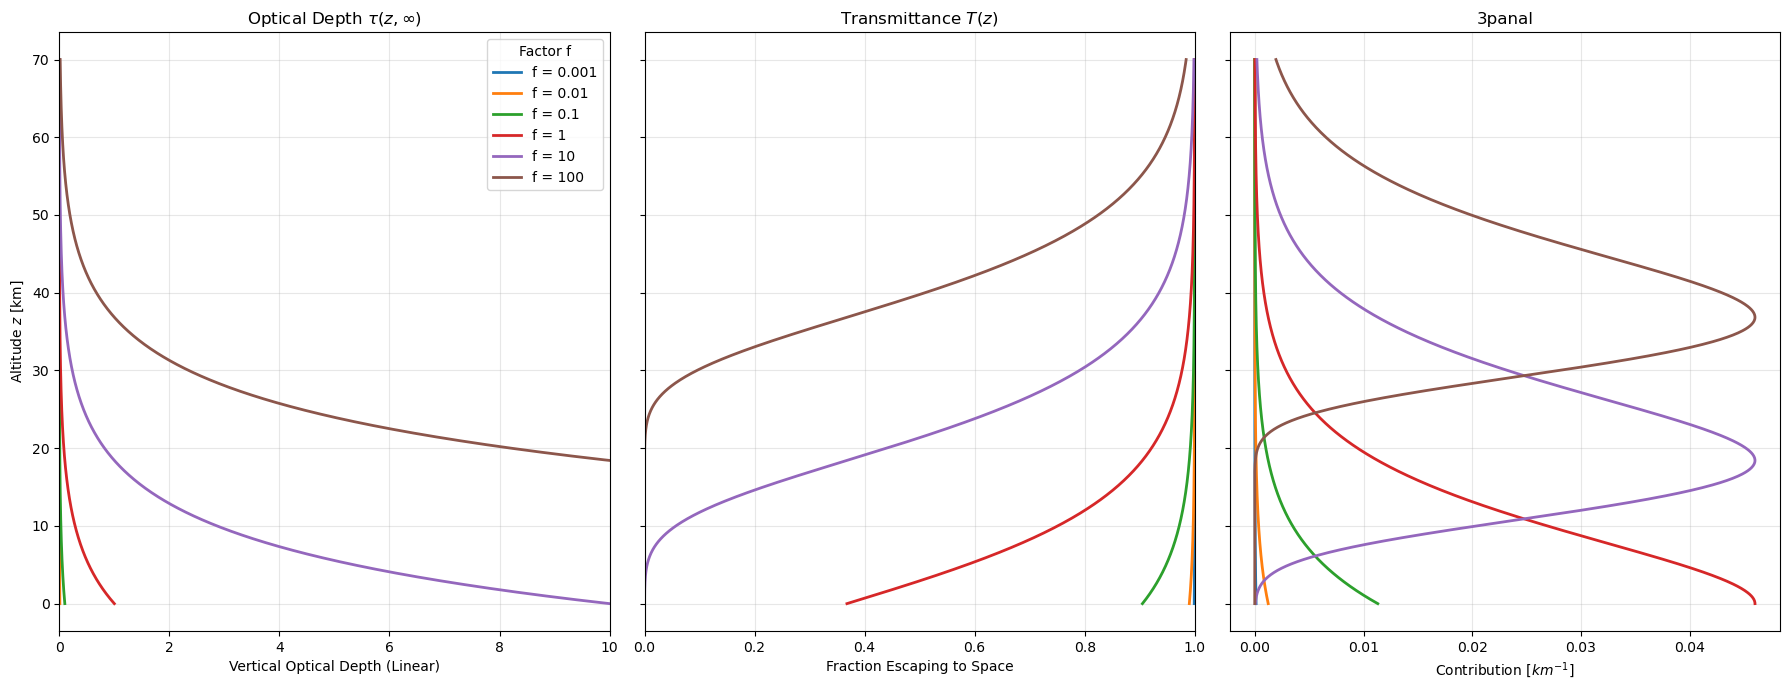

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_physics(z, f, H, mu=1.0):
    C = f * 1.25e-4
    # 1. Vertical Optical Depth from z to space
    tau = (C * H * np.exp(-z / H))
    
    # 2. Transmittance along slant path
    T = np.exp(-tau / mu)
    
    # 3. Weighting Function
    W = (C / mu) * np.exp(-z / H) * T
    return tau, T, W

# Constants
H = 8000.0  # Scale height in meters
mu = 1.0    # Zenith angle cosine
f_factors = [0.001, 0.01, 0.1, 1, 10, 100]
z = np.linspace(0, 70000, 1000) # 0 to 70 km
z_km = z / 1000

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for f in f_factors:
    tau, T, W = calculate_physics(z, f, H, mu)
    
    # Panel 1: Optical Depth (LINEAR)
    ax1.plot(tau, z_km, label=f'f = {f}', linewidth=2)
    
    # Panel 2: Transmittance
    ax2.plot(T, z_km, label=f'f = {f}', linewidth=2)
    
    # Panel 3: Weighting Function (W * 1000 to get km^-1)
    ax3.plot(W * 1000, z_km, label=f'f = {f}', linewidth=2)

# Formatting
ax1.set_xlim(0, 10)
ax1.set_title('Optical Depth $\\tau(z, \\infty)$')
ax1.set_xlabel('Vertical Optical Depth (Linear)')
ax1.set_ylabel('Altitude $z$ [km]')
ax1.grid(True, ls="-", alpha=0.3)
ax1.legend(title="Factor f")

ax2.set_title('Transmittance $T(z)$')
ax2.set_xlabel('Fraction Escaping to Space')
ax2.set_xlim(0, 1.0)
ax2.grid(True, alpha=0.3)

ax3.set_title('Weighting Function $W(z)$')
ax3.set_xlabel('Contribution [$km^{-1}$]')
ax3.grid(True, alpha=0.3)
plt.title("3panal")
save_fig()
plt.tight_layout()
plt.show()

# Part II: TOA Longwave Radiation

## TOA Outgoing Longwave Radiation

The monochromatic outgoing longwave flux at the top of the atmosphere is

$$
F_\lambda^\uparrow(\infty)
=
\int_0^\infty
\pi B_\lambda(z)
W^\uparrow(z)\,dz
$$

Substitute the weighting function:

$$
F_\lambda^\uparrow(\infty)
=
\int_0^\infty
\pi B_\lambda(z)
\left[
rCe^{-z/H}
\exp\left(
-rCHe^{-z/H}
\right)
\right]
dz
$$

Final result:

$$
\boxed{
F_\lambda^\uparrow(\infty)
=
\int_0^\infty
\pi B_\lambda(z)
rCe^{-z/H}
\exp\left(
-rCHe^{-z/H}
\right)
dz
}
$$

---

## TOA Radiative Forcing

The radiative forcing associated with changing \(f\) is

$$
\Delta F(\infty;f)
=
F^\uparrow(\infty;f)
-
F^\uparrow(\infty;f_0)
$$

Final result:

$$
\boxed{
\Delta F(\infty;f)
=
F^\uparrow(\infty;f)
-
F^\uparrow(\infty;f_0)
}
$$

---

## Physical Interpretation

Increasing \(f\) increases the optical depth:

$$
\boxed{
\tau(z,\infty) = CH e^{-z/H}
}
$$

This decreases atmospheric transmittance:

$$
\boxed{
t(z,\infty)
=
\exp\left(
-rCHe^{-z/H}
\right)
}
$$

As optical depth increases, the weighting function shifts upward in altitude (z)
to higher (and colder) atmospheric layers.

$$
\boxed{
W^\uparrow(z)
=
rCe^{-z/H}
\exp\left(
-rCHe^{-z/H}
\right)
}
$$

Emission to space decreases, reducing the outgoing
longwave radiation and producing positive radiative forcing.

$$
\boxed{
F_\lambda^\uparrow(\infty)
=
\int_0^\infty
\pi B_\lambda(z)
rCe^{-z/H}
\exp\left(
-rCHe^{-z/H}
\right)
dz
}
$$

$$
\boxed{
\Delta F(\infty;f)
=
F^\uparrow(\infty;f)
-
F^\uparrow(\infty;f_0)
}
$$

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical Constants ---
h = 6.626e-34  # Planck constant [J·s]
c = 3.0e8      # Speed of light [m/s]
kB = 1.38e-23  # Boltzmann constant [J/K]

def planck_function(wavelength_nm, temp_k):
    """Calculates spectral radiance B_lambda(T) in W/(m^2 sr m)."""
    lam = wavelength_nm * 1e-9  # convert nm to meters
    term1 = (2 * h * c**2) / (lam**5)
    term2 = np.exp((h * c) / (lam * kB * temp_k)) - 1
    return term1 / term2

def model_radiative_forcing(wavelength_nm, Ts, H, f_list, C_base=1.25e-4):
    r = 5/3  # Diffusivity factor
    z = np.linspace(0, 100000, 1000)  # 0 to 100km
    dz = z[1] - z[0]
    
    temp_z = np.full_like(z, Ts) 
    
    # Calculate B_lambda at surface and throughout atmosphere
    B_surf = planck_function(wavelength_nm, Ts)
    B_z = planck_function(wavelength_nm, temp_z)
    
    results = {}

    # Case f=0 (The Reference State)
    # Net Flux at TOA = - (Surface Flux)
    Fn_0 = - (np.pi * B_surf)
    
    print(f"--- Analysis at {wavelength_nm} nm ---")
    print(f"Reference Net Flux (f=0): {Fn_0:.4e} W/m²/m")
    
    for f in f_list:
        C = f * C_base
        
        # 1. Surface contribution reaching space
        tau_total = r * C * H
        surface_term = np.pi * B_surf * np.exp(-tau_total)
        
        # 2. Atmospheric weighting function integral
        # W_f = r * C * exp(-z/H) * exp(-r * C * H * exp(-z/H))
        transmittance = np.exp(-r * C * H * np.exp(-z/H))
        W_f = r * C * np.exp(-z/H) * transmittance
        
        # Integral of pi * B(z) * W_f over dz
        atmosphere_term = np.trapezoid(np.pi * B_z * W_f, z)
        
        # Total Upwelling Flux
        F_up = surface_term + atmosphere_term
        
        # Net Flux at TOA
        Fn_f = -F_up
        
        # Radiative Forcing: Delta F = Fn(f) - Fn(0)
        delta_F = Fn_f - Fn_0
        
        results[f] = {"Fn": Fn_f, "Forcing": delta_F}
        print(f"f = {f:<5} | Net Flux: {Fn_f:.4e} | Forcing: {delta_F:.4e}")
        
    return results

# --- User Inputs ---
target_wavelength = 15000  # Wavelength in nm 
surface_temp = 300         # Surface Temperature in Kelvin
scale_height = 8000        # Scale Height in meters
f_values = [0.001, 0.01, 0.1, 1, 10, 100]

# Run Model
forcing_data = model_radiative_forcing(target_wavelength, surface_temp, scale_height, f_values)

--- Analysis at 15000 nm ---
Reference Net Flux (f=0): -2.0946e+07 W/m²/m
f = 0.001 | Net Flux: -2.0946e+07 | Forcing: -3.2386e-01
f = 0.01  | Net Flux: -2.0947e+07 | Forcing: -3.1038e+00
f = 0.1   | Net Flux: -2.0947e+07 | Forcing: -1.9119e+01
f = 1     | Net Flux: -2.0946e+07 | Forcing: 1.8745e+02
f = 10    | Net Flux: -2.0945e+07 | Forcing: 1.3010e+03
f = 100   | Net Flux: -2.0933e+07 | Forcing: 1.3006e+04


In [70]:
import numpy as np

def planck_function(wvl_nm, temp_k):
    """Calculates B_lambda(T) - The source of the radiation."""
    h = 6.626e-34
    c = 3.0e8
    kb = 1.38e-23
    lam = wvl_nm * 1e-9
    
    exponent = (h * c) / (lam * kb * temp_k)
    # Using np.expm1 for better numerical stability at small values
    return (2 * h * c**2) / (lam**5 * np.expm1(exponent))

def calculate_parts(z, f, H, C_base=1.25e-4, r=5/3):
    """Defines the components of the Upwelling Flux equation."""
    C = f * C_base
    
    tau_z_to_space = r * C * H * np.exp(-z / H)
    
    transmittance = np.exp(-tau_z_to_space)
    
    weighting_func = r * C * np.exp(-z / H) * transmittance
    
    return tau_z_to_space, transmittance, weighting_func

f     | Fn (TOA)        | Delta F        
0.001 | -2.0933e+07 | 1.3967e+04
0.01  | -2.0807e+07 | 1.3903e+05
0.1   | -1.9618e+07 | 1.3283e+06
1     | -1.2041e+07 | 8.9051e+06
10    | -4.2546e+06 | 1.6692e+07
100   | -4.0859e+06 | 1.6861e+07
Successfully saved to: figures/Radiative_Forcing_vs_Gas_Concentration_Scaling.png


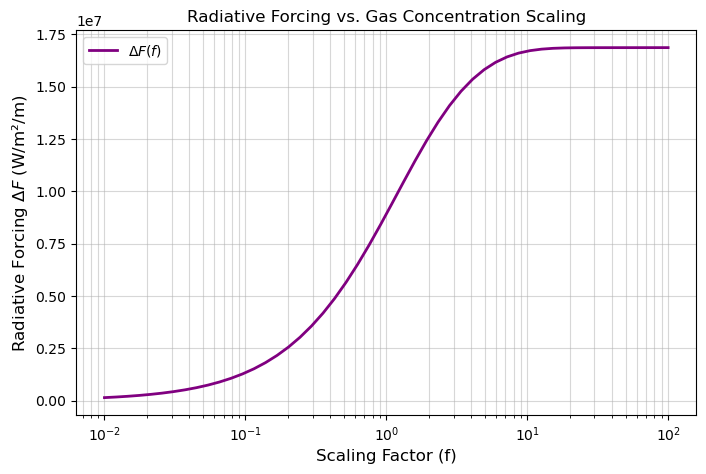

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters 
wavelength = 15000  # 15 micrometers
Ts = 300            # Surface Temperature (K)
r = 5/3             # Diffusivity factor
H = 8000            # Scale height (m)
TOA = 100000        # TOA height (m)
C_base = 1.25e-4    # Base concentration
f_values = [0.001, 0.01, 0.1, 1, 10, 100]

# --- 2. Physics Functions ---
def get_B(temp):
    """Planck Function B_lambda(T)"""
    h, c, kb = 6.626e-34, 3.0e8, 1.38e-23
    lam = wavelength * 1e-9
    return (2 * h * c**2) / (lam**5 * np.expm1((h * c) / (lam * kb * temp)))

def run_model(f, lapse_rate):
    """Calculates Net Flux at TOA for a given f and lapse rate (K/m)"""
    z = np.linspace(0, TOA, 2000)
    T_z = np.maximum(Ts - lapse_rate * z, 200) # Temp profile 
    
    C = f * C_base
    tau_z = r * C * H * np.exp(-z/H)
    W_f = (r * C * np.exp(-z/H)) * np.exp(-tau_z)
    
    # Components
    B_s = get_B(Ts)
    B_z = get_B(T_z)
    
    surf_term = np.pi * B_s * np.exp(-r * C * H)
    atm_term = np.trapezoid(np.pi * B_z * W_f, z) if hasattr(np, 'trapz') else np.trapezoid(np.pi * B_z * W_f, z)
    
    Fn = -(surf_term + atm_term)
    return Fn

# --- 3. Execution & Comparison ---
gamma = 6.5 / 1000 # Standard 6.5 K/km
Fn_0 = run_model(0, gamma)

print(f"{'f':<5} | {'Fn (TOA)':<15} | {'Delta F':<15}")
for f in f_values:
    Fn = run_model(f, gamma)
    dF = Fn - Fn_0
    print(f"{f:<5} | {Fn:10.4e} | {dF:10.4e}")

# --- 4. Plotting Delta F vs f ---


f_plot = np.logspace(-2, 2, 50)  # f from 0.01 to 100
df_results = []

for f in f_plot:
    Fn = run_model(f, gamma)
    df_results.append(Fn - Fn_0)

plt.figure(figsize=(8, 5))
plt.plot(f_plot, df_results, color='purple', linewidth=2, label=r'$\Delta F(f)$')

# Formatting the plot
plt.xscale('log') # Log scale 
plt.xlabel('Scaling Factor (f)', fontsize=12)
plt.ylabel('Radiative Forcing $\Delta F$ (W/m²/m)', fontsize=12)
plt.title('Radiative Forcing vs. Gas Concentration Scaling', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.title("Radiative Forcing vs. Gas Concentration Scaling")
save_fig()
plt.show()

In [72]:
import numpy as np



def planck_function(wvl_nm, temp_k):
    """Calculates spectral radiance B_lambda(T)."""
    h, c, kb = 6.626e-34, 3.0e8, 1.38e-23
    lam = wvl_nm * 1e-9
    return (2 * h * c**2) / (lam**5 * np.expm1((h * c) / (lam * kb * temp_k)))

def run_simulation(f_list, wavelength, surface_temp, scale_height, settings):
    """Calculates TOA Net Flux and Forcing for a list of f values."""
    r = 5/3
    C_base = 1.25e-4 
    z = np.linspace(0, 50000, 1000) # 0 to 50km
    
    #  TEMPERATURE PROFILE SELECTION
    if settings["isothermal"]:
        temp_z = np.full_like(z, surface_temp)
        profile_name = "Isothermal"
    else:
       
        if settings["use_gamma_d"]:
            gamma = 5 / 1000  # 5 K/km
            profile_name = "Gamma_d (5 K/km)"
        elif settings["use_gamma_s"]:
            gamma = -2 / 1000 # -2 K/km (Inversion)
            profile_name = "Gamma_s (-2 K/km inversion)"
        else:
            gamma = settings["custom_gamma"] / 1000
            profile_name = f"Custom ({settings['custom_gamma']} K/km)"
            
        temp_z = surface_temp - (gamma * z)
        temp_z = np.maximum(temp_z, 100) 

    B_z = planck_function(wavelength, temp_z)
    B_s = planck_function(wavelength, surface_temp)
    
    # 3. RADIATIVE CALCULATIONS
    Fn_zero = -(np.pi * B_s) # Reference state (no gas)
    
    print(f"\n--- Simulation: {profile_name} ---")
    print(f"{'f-value':<10} | {'Net Flux (TOA)':<15} | {'Forcing (ΔF)':<15}")
    print("-" * 50)

    results = []

    # Pre-calculate f=0 baseline for Radiative Forcing
    B_s = planck_function(wavelength, surface_temp)
    Fn_zero = -(np.pi * B_s)

    for f in f_list:
    # 1. Update the concentration based on scaling factor
        C = f * C_base
    
        # 2. Surface Term Calculation
        # Uses total column optical depth (r * C * H)
        tau_total = r * C * scale_height
        surface_contribution = np.pi * B_s * np.exp(-tau_total)
    
        # 3. Atmospheric Term Calculation 
        # Define the local optical depth from height 'z' to space
        # tau(z) = r * C * H * exp(-z/H)
        tau_z = r * C * scale_height * np.exp(-z / scale_height)
    
        
        # W_f = (Emission Strength at z) * (Transmittance to space)
        W_f = (r * C * np.exp(-z / scale_height)) * np.exp(-tau_z)
    
        # Perform the integration: integral of pi * B(z) * W_f(z) dz
        try:
            atm_contribution = np.trapezoid(np.pi * B_z * W_f, z)
        except AttributeError:
            atm_contribution = np.trapezoid(np.pi * B_z * W_f, z)
        
        # 4. Final Flux and Forcing Assembly
        F_up_total = surface_contribution + atm_contribution
        Fn_f = -F_up_total  # Net flux at TOA (Fn = F_down - F_up)
    
        # Radiative Forcing: Delta F = Fn(f) - Fn(0)
        delta_F = Fn_f - Fn_zero
    
        # 5. Store and Print
        results.append({
            'f': f, 
            'Fn': Fn_f, 
            'Forcing': delta_F,
            'surf_contrib': surface_contribution,
            'atm_contrib': atm_contribution
    })
    
    print(f"f={f:<5} | Net Flux: {Fn_f:.4e} | Forcing: {delta_F:.4e}")

# --- 4. INPUTS & LOGIC GATES ---

f_values = [0, 1, 10, 100]

# Toggle these to change the atmosphere behavior
my_settings = {
    "isothermal": False,      # Set to True for T(z) = Ts
    "use_gamma_d": True,      # Set to True for 5 K/km
    "use_gamma_s": False,     # Set to True for -2 K/km (Inversion)
    "custom_gamma": 6.5       # Only used if all above are False
}

# Run simulation
run_simulation(f_values, 15000, 288, 8000, my_settings)


--- Simulation: Gamma_d (5 K/km) ---
f-value    | Net Flux (TOA)  | Forcing (ΔF)   
--------------------------------------------------
f=100   | Net Flux: -5.9527e+04 | Forcing: 1.8175e+07



--- Model Verification: Case 1: Isothermal (0 K/km) ---
f-value    | Net Flux (Fn)      | Forcing (ΔF)   
--------------------------------------------------
0.001      | -2.0946e+07 | 1.6724e-02
0.01       | -2.0946e+07 | 2.0090e-01
0.1        | -2.0946e+07 | 4.9857e+00
1          | -2.0946e+07 | 1.4442e+02
10         | -2.0945e+07 | 1.3010e+03
100        | -2.0933e+07 | 1.3006e+04
Successfully saved to: figures/Radiative_ForcingIsothermal.png


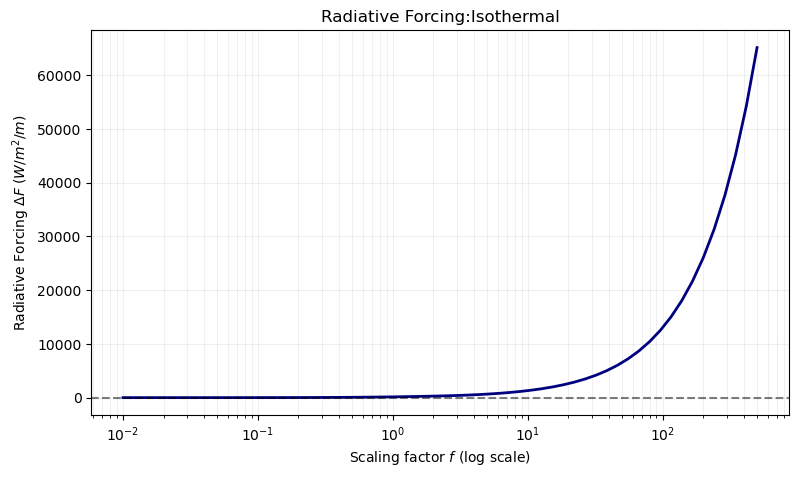

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. MANUAL INPUT VARIABLES
# ==========================================
wavelength = 15000   # nm (15um)
Ts = 300             # Surface Temp (K)
r = 5/3              # Diffusivity factor
H = 8000             # Scale height (m)
C_base = 1.25e-4     # Base absorption
z_max = 100000       # 100km TOA
num_points = 2000

# --- INVERSION LOGIC ---
is_inversion = False  # Set to True for Inversion, False for Standard
use_tropopause = True  # Set to True to cap temperature at a minimum value

if is_inversion:
    gamma = -2 / 1000  # Gamma_s: -2 K/km (Inversion)
    label = "Inversion Case (-2 K/km)"
else:
    gamma = 0 / 1000   # Gamma_d: 0 K/km 
    label = "Case 1: Isothermal (0 K/km)"

# Create the profile
z = np.linspace(0, z_max, num_points)
temp_z = Ts - gamma * z

if use_tropopause:
    temp_z = np.maximum(temp_z, 217) 


def get_planck_radiance(temp, wvl_nm):
    h, c, kb = 6.626e-34, 3.0e8, 1.38e-23
    lam = wvl_nm * 1e-9
    return (2 * h * c**2) / (lam**5 * np.expm1((h * c) / (lam * kb * temp)))

def compute_toa_flux(f_val):
    C = f_val * C_base
    tau_z = r * C * H * np.exp(-z/H)
    W_f = (r * C * np.exp(-z/H)) * np.exp(-tau_z)
    
    B_z = get_planck_radiance(temp_z, wavelength)
    B_s = get_planck_radiance(Ts, wavelength)
    
    total_tau = r * C * H
    surface_term = np.pi * B_s * np.exp(-total_tau)
    
    try:
        atm_term = np.trapezoid(np.pi * B_z * W_f, z)
    except AttributeError:
        atm_term = np.trapezoid(np.pi * B_z * W_f, z)
        
    return -(surface_term + atm_term)

# ==========================================
# 3. PLOTTING
# ==========================================
f_values_to_print = [0.001, 0.01, 0.1, 1, 10, 100] # Specific f-values for the table
Fn_0 = compute_toa_flux(0)

print(f"\n--- Model Verification: {label} ---")
print(f"{'f-value':<10} | {'Net Flux (Fn)':<18} | {'Forcing (ΔF)':<15}")
print("-" * 50)

for f in f_values_to_print:
    Fn_f = compute_toa_flux(f)
    delta_F = Fn_f - Fn_0
    print(f"{f:<10} | {Fn_f:10.4e} | {delta_F:10.4e}")
    
f_values = np.logspace(-2, 2.7, 60)
Fn_0 = compute_toa_flux(0)
dF = [compute_toa_flux(f) - Fn_0 for f in f_values]

plt.figure(figsize=(9, 5))
plt.plot(f_values, dF, color='darkred' if is_inversion else 'navy', lw=2)
plt.xscale('log')
plt.axhline(0, color='black', alpha=0.5, linestyle='--')
plt.xlabel('Scaling factor $f$ (log scale)')
plt.ylabel('Radiative Forcing $\Delta F$ ($W/m^2/m$)')
plt.title(f'Radiative Forcing: {label}')
plt.grid(True, which="both", alpha=0.2)
plt.title("Radiative Forcing:Isothermal")
save_fig()
plt.show()

## Why the $\Delta F$ value is not 0 for every scaling factor

As the scaling factor increases, the model shifts from emission of radiation from the surface straight back to space to atmospheric emission, defined by the diffusivity value 5/3, since the temperature is constant with height. Since the emission direction is dictated by r=5/3 for the atmosphere, as f increases, the increasing gas-molecule concentration begins to emit radiation in many directions, thereby raising $\Delta F$ by retaining some of the outgoing radiation before it reaches TOA. In this case, as f increases, the weighting function also increases in peak z value, but since the temperature is constant with altitude, the diffusivity factor is the driving force for positive radiative forcing. 


--- Model Verification: Case 1: Constant Lapse Rate (1 K/km) ---
f-value    | Net Flux (Fn)      | Forcing (ΔF)   
--------------------------------------------------
0.001      | -2.0944e+07 | 2.9790e+03
0.01       | -2.0917e+07 | 2.9676e+04
0.1        | -2.0661e+07 | 2.8580e+05
1          | -1.8878e+07 | 2.0686e+06
10         | -1.5131e+07 | 5.8151e+06
100        | -1.1669e+07 | 9.2777e+06
Successfully saved to: figures/Radiative_Forcingconstant_lapse.png


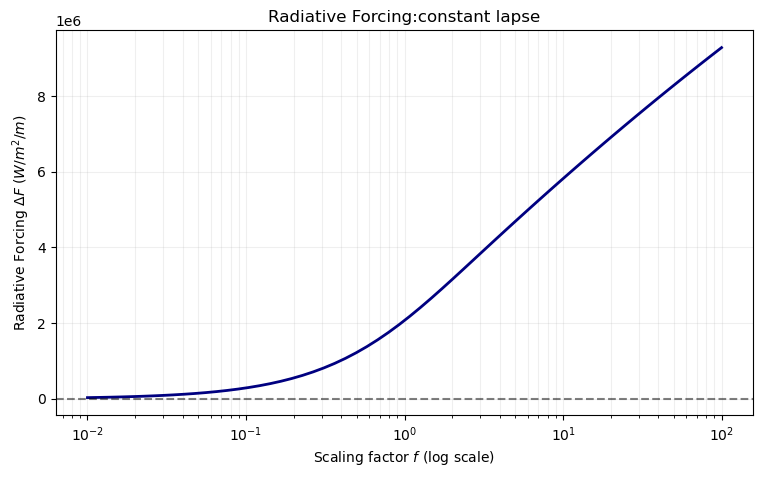

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. MANUAL INPUT VARIABLES
# ==========================================
wavelength = 15000   # nm (15um)
Ts = 300             # Surface Temp (K)
r = 5/3              # Diffusivity factor
H = 8000             # Scale height (m)
C_base = 1.25e-4     # Base absorption
z_max = 100000       # 100km TOA
num_points = 2000

# --- INVERSION LOGIC ---
is_inversion = False  # Set to True for Inversion, False for Standard
use_tropopause = True  # Set to True to cap temperature at a minimum value

if is_inversion:
    gamma = -2 / 1000  # Gamma_s: -2 K/km (Inversion)
    label = "Inversion Case (-2 K/km)"
else:
    gamma = 1 / 1000   # Gamma_d: 1 K/km 
    label = "Case 1: Constant Lapse Rate (1 K/km)"

# Create the profile
z = np.linspace(0, z_max, num_points)
temp_z = Ts - gamma * z

if use_tropopause:
    temp_z = np.maximum(temp_z, 217) 


def get_planck_radiance(temp, wvl_nm):
    h, c, kb = 6.626e-34, 3.0e8, 1.38e-23
    lam = wvl_nm * 1e-9
    return (2 * h * c**2) / (lam**5 * np.expm1((h * c) / (lam * kb * temp)))

def compute_toa_flux(f_val):
    C = f_val * C_base
    tau_z = r * C * H * np.exp(-z/H)
    W_f = (r * C * np.exp(-z/H)) * np.exp(-tau_z)
    
    B_z = get_planck_radiance(temp_z, wavelength)
    B_s = get_planck_radiance(Ts, wavelength)
    
    total_tau = r * C * H
    surface_term = np.pi * B_s * np.exp(-total_tau)
    
    try:
        atm_term = np.trapezoid(np.pi * B_z * W_f, z)
    except AttributeError:
        atm_term = np.trapezoid(np.pi * B_z * W_f, z)
        
    return -(surface_term + atm_term)

# ==========================================
# 3. PLOTTING
# ==========================================
f_values_to_print = [0.001, 0.01, 0.1, 1, 10, 100] # Specific f-values for the table
Fn_0 = compute_toa_flux(0)

print(f"\n--- Model Verification: {label} ---")
print(f"{'f-value':<10} | {'Net Flux (Fn)':<18} | {'Forcing (ΔF)':<15}")
print("-" * 50)

for f in f_values_to_print:
    Fn_f = compute_toa_flux(f)
    delta_F = Fn_f - Fn_0
    print(f"{f:<10} | {Fn_f:10.4e} | {delta_F:10.4e}")


f_plot = np.logspace(-2, 2, 60)
dF_plot = [compute_toa_flux(f) - Fn_0 for f in f_plot]
f_values = np.logspace(-2, 2, 60)
Fn_0 = compute_toa_flux(0)
dF = [compute_toa_flux(f) - Fn_0 for f in f_values]

plt.figure(figsize=(9, 5))
plt.plot(f_values, dF, color='darkred' if is_inversion else 'navy', lw=2)
plt.xscale('log')
plt.axhline(0, color='black', alpha=0.5, linestyle='--')
plt.xlabel('Scaling factor $f$ (log scale)')
plt.ylabel('Radiative Forcing $\Delta F$ ($W/m^2/m$)')
plt.title(f'Radiative Forcing: {label}')
plt.grid(True, which="both", alpha=0.2)
plt.title("Radiative Forcing:constant lapse")
save_fig()
plt.show()

# Constant Lapse Rate: Linear increase in $\Delta F$ with increasing Concentration scaling factor (f)

As f increases the peak z of the weighting function increases. Since the lapse rate is a constant 1 K/km the majority of emission is occuring at higher (colder) atmomspheric altitudes as the concentration scaling factor increases. The emission from colder atmospheric temperatures makes the overall radiative forcing more positive since less radiation/energy is escaping to the TOA. 


--- Model Verification: Inversion Case (-1 K/km) ---
f-value    | Net Flux (Fn)      | Forcing (ΔF)   
--------------------------------------------------
0.001      | -2.0950e+07 | -3.2228e+03
0.01       | -2.0979e+07 | -3.2110e+04
0.1        | -2.1256e+07 | -3.0969e+05
1          | -2.3218e+07 | -2.2716e+06
10         | -2.7720e+07 | -6.7736e+06
100        | -3.2685e+07 | -1.1738e+07
Successfully saved to: figures/Radiative_ForcingInversion.png


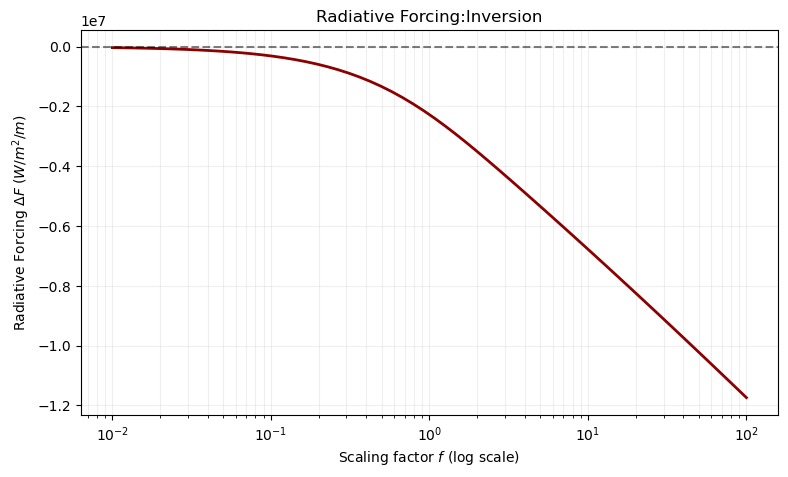

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. MANUAL INPUT VARIABLES
# ==========================================
wavelength = 15000   # nm (15um)
Ts = 300             # Surface Temp (K)
r = 5/3              # Diffusivity factor
H = 8000             # Scale height (m)
C_base = 1.25e-4     # Base absorption
z_max = 100000       # 100km TOA
num_points = 2000

# --- INVERSION LOGIC ---
is_inversion = True  # Set to True for Inversion, False for Standard
use_tropopause = False  # Set to True to cap temperature at a minimum value

if is_inversion:
    gamma = -1 / 1000  # Gamma_s: -1 K/km (Inversion)
    label = "Inversion Case (-1 K/km)"
else:
    gamma = 1 / 1000   # Gamma_d: 1 K/km 
    label = "Case 1: Constant Lapse Rate (1 K/km)"

# Create the profile
z = np.linspace(0, z_max, num_points)
temp_z = Ts - gamma * z


if use_tropopause:

    temp_z = np.maximum(temp_z, 217) 

# ==========================================
# 2. PHYSICS CORE
# ==========================================
def get_planck_radiance(temp, wvl_nm):
    h, c, kb = 6.626e-34, 3.0e8, 1.38e-23
    lam = wvl_nm * 1e-9
    return (2 * h * c**2) / (lam**5 * np.expm1((h * c) / (lam * kb * temp)))

def compute_toa_flux(f_val):
    C = f_val * C_base
    tau_z = r * C * H * np.exp(-z/H)
    W_f = (r * C * np.exp(-z/H)) * np.exp(-tau_z)
    
    B_z = get_planck_radiance(temp_z, wavelength)
    B_s = get_planck_radiance(Ts, wavelength)
    
    total_tau = r * C * H
    surface_term = np.pi * B_s * np.exp(-total_tau)
    
    try:
        atm_term = np.trapezoid(np.pi * B_z * W_f, z)
    except AttributeError:
        atm_term = np.trapezoid(np.pi * B_z * W_f, z)
        
    return -(surface_term + atm_term)

# ==========================================
# 3. PLOTTING
# ==========================================
f_values_to_print = [0.001, 0.01, 0.1, 1, 10, 100] # Specific f-values for the table
Fn_0 = compute_toa_flux(0)

print(f"\n--- Model Verification: {label} ---")
print(f"{'f-value':<10} | {'Net Flux (Fn)':<18} | {'Forcing (ΔF)':<15}")
print("-" * 50)

for f in f_values_to_print:
    Fn_f = compute_toa_flux(f)
    delta_F = Fn_f - Fn_0
    print(f"{f:<10} | {Fn_f:10.4e} | {delta_F:10.4e}")
    
f_values = np.logspace(-2, 2, 60)
Fn_0 = compute_toa_flux(0)
dF = [compute_toa_flux(f) - Fn_0 for f in f_values]

plt.figure(figsize=(9, 5))
plt.plot(f_values, dF, color='darkred' if is_inversion else 'navy', lw=2)
plt.xscale('log')
plt.axhline(0, color='black', alpha=0.5, linestyle='--')
plt.xlabel('Scaling factor $f$ (log scale)')
plt.ylabel('Radiative Forcing $\Delta F$ ($W/m^2/m$)')
plt.title(f'Radiative Forcing: {label}')
plt.grid(True, which="both", alpha=0.2)
plt.title("Radiative Forcing:Inversion")
save_fig()
plt.show()

# Constant Inversion Lapse Rate: Linear Decrease in $\Delta F$ with Increasing Concentration Scaling Factor

In the inversion lapse rate scenario, the atmosphere increases in temperature with height. This shows the oposite effect on radiative forcing as seen in case 2, because $\Delta F$ becomes increasingly negative with increasing f. As the f increases the weighting function peaks at higher altitudes which in this case correlate to higher atmospheric temperatures. The higher temperatures correspond to increased energy relative to the surface temp leaving the atmosphere resulting in a negative radiative forcing. 

f_20km: 7.309496376422084, f_50km: 310.8076948010052
Successfully saved to: figures/The_Radiative_Source_Planck_Function_vs_Altitude.png


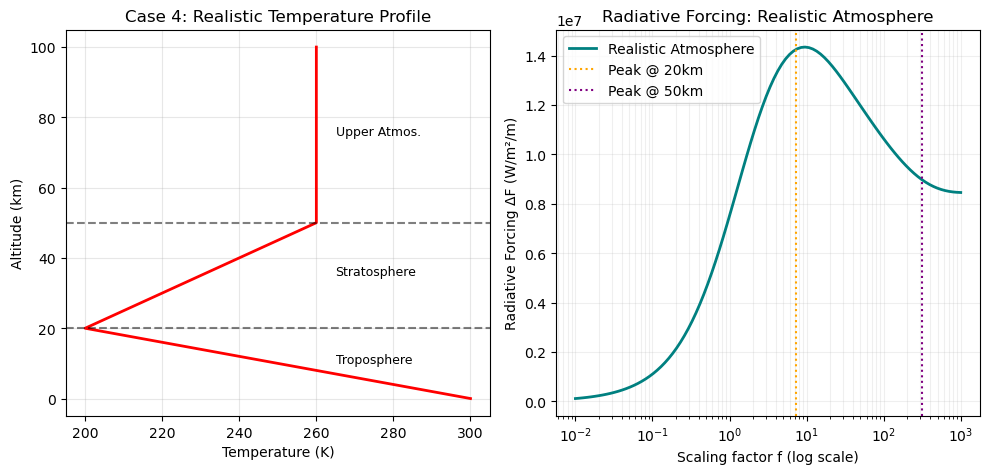

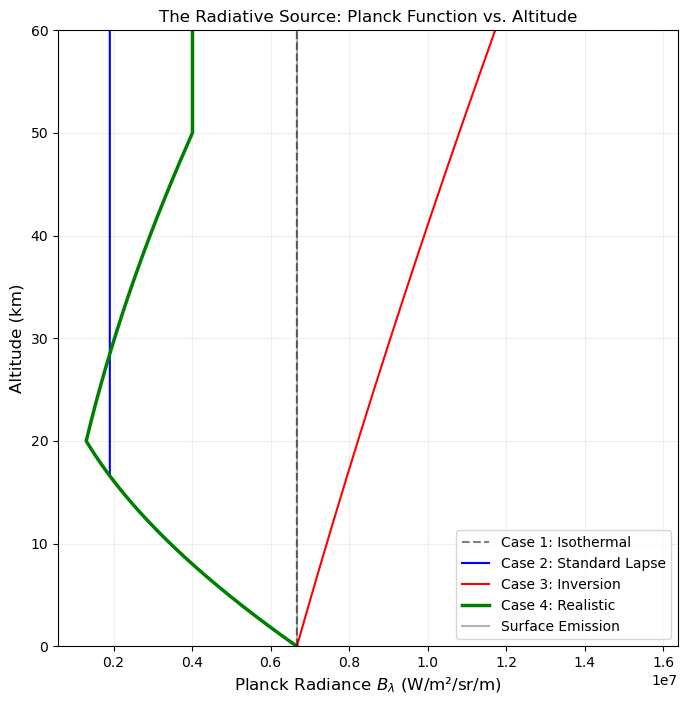

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
wavelength = 15000
Ts = 300
r = 5/3
H = 8000
C_base = 1.25e-4
z_max = 100000
z = np.linspace(0, z_max, 5000)
f_values = np.logspace(-2, 3, 100)

def get_planck_radiance(temp, wvl_nm):
    h, c, kb = 6.626e-34, 3.0e8, 1.38e-23
    lam = wvl_nm * 1e-9
    return (2 * h * c**2) / (lam**5 * np.expm1((h * c) / (lam * kb * temp)))

# Case 4: Realistic Atmosphere Temperature Profile
Gamma_d = 5 / 1000
Gamma_s = -2 / 1000
temp_z = np.zeros_like(z)
for i, height in enumerate(z):
    if height <= 20000:
        temp_z[i] = 300 - Gamma_d * height
    elif height <= 50000:
        temp_z[i] = 200 - Gamma_s * (height - 20000)
    else:
        temp_z[i] = 260

def compute_toa_flux(f_val):
    C = f_val * C_base
    tau_total = r * C * H
    tau_z = r * C * H * np.exp(-z/H)
    W_f = (r * C * np.exp(-z/H)) * np.exp(-tau_z)
    B_z = get_planck_radiance(temp_z, wavelength)
    B_s = get_planck_radiance(Ts, wavelength)
    surface_term = np.pi * B_s * np.exp(-tau_total)
    atm_term = np.trapezoid(np.pi * B_z * W_f, z)
    return -(surface_term + atm_term)

# Calculations
Fn_0 = compute_toa_flux(0)
dF = [compute_toa_flux(f) - Fn_0 for f in f_values]

# Find transition f values (where peak height z_peak = 20km and 50km)
# z_peak = H * ln(r * f * C_base * H)  => f = exp(z_peak/H) / (r * C_base * H)
denom = r * C_base * H
f_20km = np.exp(20000 / H) / denom
f_50km = np.exp(50000 / H) / denom

# Plot 1: Temperature Profile (Verification)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(temp_z, z/1000, color='red', lw=2)
plt.axhline(20, color='black', linestyle='--', alpha=0.5)
plt.axhline(50, color='black', linestyle='--', alpha=0.5)
plt.text(265, 10, 'Troposphere', fontsize=9)
plt.text(265, 35, 'Stratosphere', fontsize=9)
plt.text(265, 75, 'Upper Atmos.', fontsize=9)
plt.xlabel("Temperature (K)")
plt.ylabel("Altitude (km)")
plt.title("Case 4: Realistic Temperature Profile")
plt.grid(True, alpha=0.3)

# Plot 2: Forcing vs Scaling Factor
plt.subplot(1, 2, 2)
plt.plot(f_values, dF, color='teal', lw=2, label='Realistic Atmosphere')
plt.xscale('log')

# Adding lines for regime transitions
if f_values[0] <= f_20km <= f_values[-1]:
    plt.axvline(f_20km, color='orange', linestyle=':', label='Peak @ 20km')
if f_values[0] <= f_50km <= f_values[-1]:
    plt.axvline(f_50km, color='purple', linestyle=':', label='Peak @ 50km')

plt.xlabel('Scaling factor f (log scale)')
plt.ylabel('Radiative Forcing ΔF (W/m²/m)')
plt.title('Radiative Forcing: Realistic Atmosphere')
plt.grid(True, which="both", alpha=0.2)
plt.legend()

plt.tight_layout()
plt.savefig('realistic_forcing_analysis.png')
print(f"f_20km: {f_20km}, f_50km: {f_50km}")
# ==========================================
# 5. PLANCK FUNCTION ANALYSIS
# ==========================================
def plot_planck_profiles():
    plt.figure(figsize=(8, 8))
    
    # 1. Case 1: Isothermal (300K)
    T_iso = np.full_like(z, 300)
    B_iso = [get_B(t) for t in T_iso]
    plt.plot(B_iso, z/1000, label='Case 1: Isothermal', color='gray', linestyle='--')

    # 2. Case 2: Standard Lapse Rate (5 K/km, cap at 217K)
    T_std = np.maximum(300 - (5/1000)*z, 217)
    B_std = [get_B(t) for t in T_std]
    plt.plot(B_std, z/1000, label='Case 2: Standard Lapse', color='blue')

    # 3. Case 3: Simple Inversion (+1 K/km)
    T_inv = 300 + (1/1000)*z
    B_inv = [get_B(t) for t in T_inv]
    plt.plot(B_inv, z/1000, label='Case 3: Inversion', color='red')

    # 4. Case 4: Realistic (Piecewise)
    B_real = [get_B(t) for t in temp_z]
    plt.plot(B_real, z/1000, label='Case 4: Realistic', color='green', lw=2.5)

    # Formatting
    plt.axvline(get_B(300), color='black', alpha=0.3, label='Surface Emission')
    plt.xlabel('Planck Radiance $B_\lambda$ (W/m²/sr/m)', fontsize=12)
    plt.ylabel('Altitude (km)', fontsize=12)
    plt.title('The "Radiative Source": Planck Function vs. Altitude', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.ylim(0, 60) # Focus on the active atmosphere
    plt.title("The Radiative Source: Planck Function vs. Altitude")
    save_fig()
    plt.show()

plot_planck_profiles()

# Realistic Atmosphere

The $\Delta F$ vs. change in f plot dynamically adjusts according to the temperature profiles, emulating tropospheric and stratospheric conditions. This is a combination of the more rudimentary cases above, where the constant lapse rate is indicative of the troposphere (although not as extreme) and the inversion regime is indicative of the stratosphere. This is reflected by the parabolic curve shown in the $\Delta F$ vs change in f plot, where the forcing is positively increasing as the lapse rate is 5 K/km from 0 to 20km, and shifts towards decreasing forcing when the lapse rate changes to -2 K/km from 20 to 50 km, and then shifts towards a more constant forcing past 50 km. 

# Part III Student Investigation: Polychromatic Model of Radiative Forcing with Constant Concentration

## Primary Question

What if I change the monochromatic wavelength model (with f as the changing variable) to a polychromatic model (with f constant)? How do the radiative forcing, radiance, and SFC plank function compare to each other?

### Secondary question 

At what spectral wavelength does the atmospheric contribution in a realistic atmosphere (case 4 with f=1) overtake the surface emission term in the $\Delta F$ function?

## Experimental Method

I altered my model to hold the concentration constant and instead evaluate the changes in radiative forcing as wavelengths vary from ~0 to 30 µm. I also wanted to compare the plots of Planck's law for the surface blackbody radiation with the emission at TOA and the $\Delta F$ across the array of wavelengths to observe shifts in peak width/height and correlate them to expected behaviors.

## Results 

For a constant scaling factor (f=1) in the realistic atmosphere regime (case 4), the $\Delta F$ as a function of wavelength peaks at 8.87µm, while the Sfc plank function (300K f=0) peaks at 9.60µm, and the TOA radiance peaks at 10.47µm. 

### SFC plank function peak @ 9.60 µm 

This peak wavelength corresponds to around 302 K using Wien's displacement law

$$
\lambda_{\max} T = b
$$

$$
T
=
\frac{2898}{\lambda_{\max}}
\quad
(\mathrm{K})
$$


$$
\lambda_{\max}
=
\frac{2898}{302}
\quad
= 9.60 (\mu\mathrm{m})
$$

Which is close to the input surface temp of 300K and aligns with the expected behavior, assuming f=0 for this value, so there is no expected atmospheric component to the emitted radiation

### TOA radiance peak @ 10.47 µm

The shift to a longer wavelength indicates that the majority of the emitted radiation at the TOA is from a lower temperature, 277 K, according to Wien's law. This corresponds to a higher z value, which is expected since the TOA radiance is for f=1; an increased optical depth leads to a maximum in the weighting function at a higher altitude, which, in this realistic atmospheric regime, is colder than the surface. 

### $\Delta F$ Radiative Forcing peak @ 8.87 µm

The peak for $\Delta F$ is at a lower wavelength than the previous two. This is because the $\Delta F$ is measuring the maximum wavelength for suppressed radiation exiting the atmosphere. Since this equation is a function of both the contributions of surface emission and atmospheric emission, the peak would occur where the trade-off between these two values yields maximum retention. This would make sense that the wavelength is slightly lower than the surface peak, since, according to the equation below, the maximum wavelength occurs where the difference between the weighting functions is maximized. 

$$
\boxed{
\Delta F_\lambda(\infty;f)
=
\int_0^\infty
\pi B_\lambda(z)
\left[
W^\uparrow(z;f)
-
W^\uparrow(z;f_0)
\right]
dz
}
$$ 

### What wavelength does the surface emission contribution go below 50% of the total?

At wavelengths less than 4.1µm, surface emission and, consequently, atmospheric emission are small. After this transition point, the surface emission increases rapidly, and the atmospheric contribution also increases due to this emission. This 4.1 µm value represents the shift from shortwave radiation, which is not readily emitted by terrestrial blackbody radiators at 300K, to IR wavelengths at which the surface emits much more readily. 
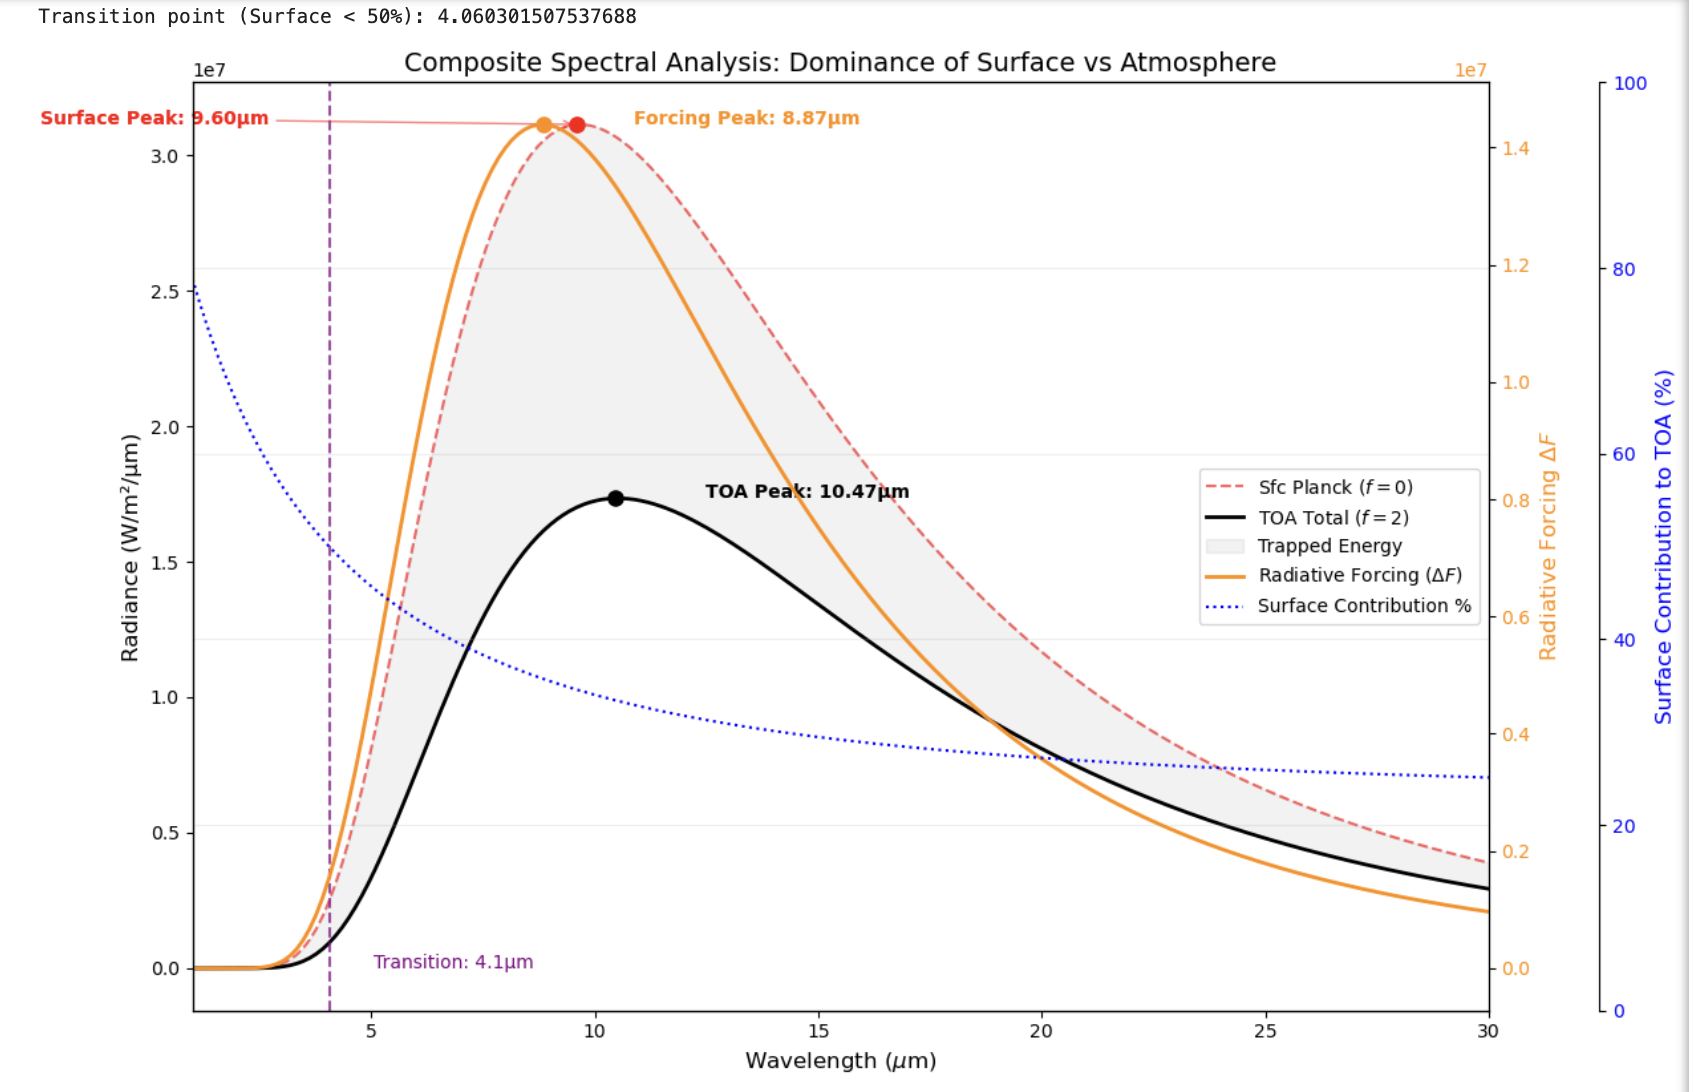

Successfully saved to: figures/Case_4_Realistic_Temperature_Profile.png
f_20km: 7.309496376422084, f_50km: 310.8076948010052
Successfully saved to: figures/Spectral_Sensitivity_(Case_4).png


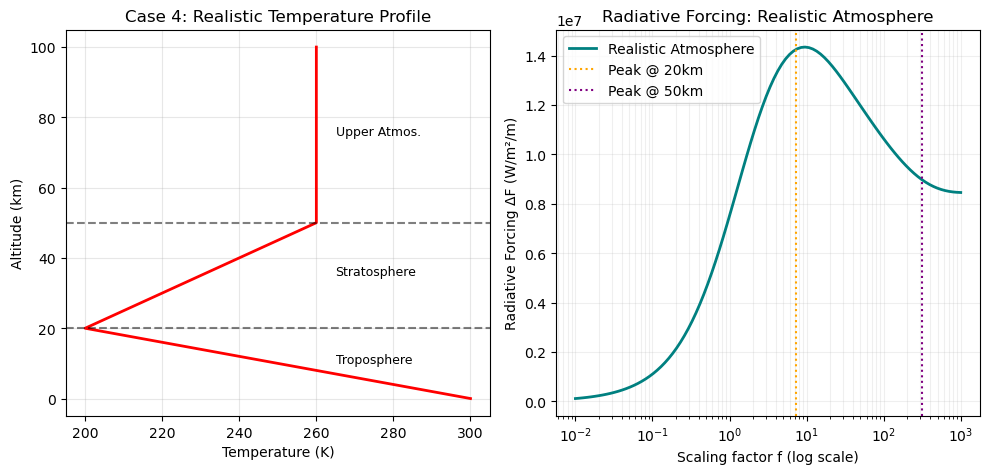

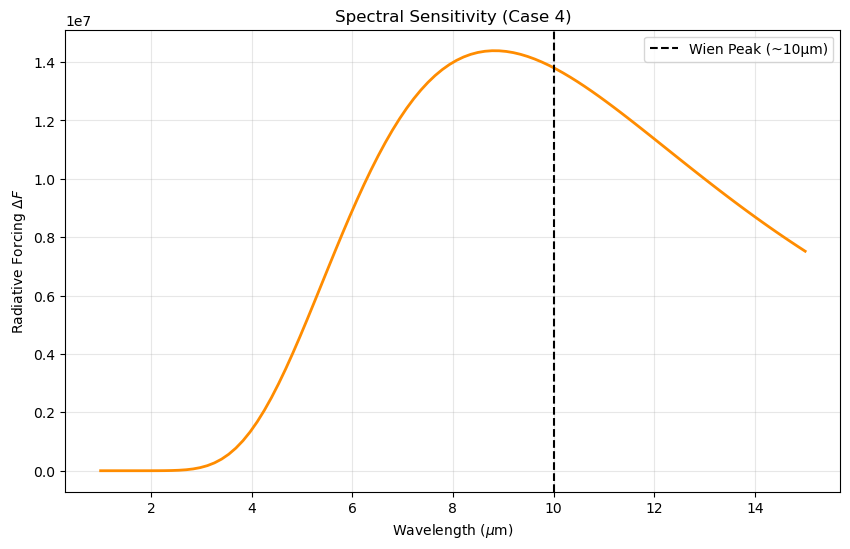

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
wavelength = 15000
Ts = 300
r = 5/3
H = 8000
C_base = 1.25e-4
z_max = 100000
z = np.linspace(0, z_max, 5000)
f_values = np.logspace(-2, 3, 100)

def get_planck_radiance(temp, wvl_nm):
    h, c, kb = 6.626e-34, 3.0e8, 1.38e-23
    lam = wvl_nm * 1e-9
    return (2 * h * c**2) / (lam**5 * np.expm1((h * c) / (lam * kb * temp)))

# Case 4: Realistic Atmosphere Temperature Profile
Gamma_d = 5 / 1000
Gamma_s = -2 / 1000
temp_z = np.zeros_like(z)
for i, height in enumerate(z):
    if height <= 20000:
        temp_z[i] = 300 - Gamma_d * height
    elif height <= 50000:
        temp_z[i] = 200 - Gamma_s * (height - 20000)
    else:
        temp_z[i] = 260

def compute_toa_flux(f_val):
    C = f_val * C_base
    tau_total = r * C * H
    tau_z = r * C * H * np.exp(-z/H)
    W_f = (r * C * np.exp(-z/H)) * np.exp(-tau_z)
    B_z = get_planck_radiance(temp_z, wavelength)
    B_s = get_planck_radiance(Ts, wavelength)
    surface_term = np.pi * B_s * np.exp(-tau_total)
    atm_term = np.trapezoid(np.pi * B_z * W_f, z)
    return -(surface_term + atm_term)

# Calculations
Fn_0 = compute_toa_flux(0)
dF = [compute_toa_flux(f) - Fn_0 for f in f_values]

# Find transition f values (where peak height z_peak = 20km and 50km)
# z_peak = H * ln(r * f * C_base * H)  => f = exp(z_peak/H) / (r * C_base * H)
denom = r * C_base * H
f_20km = np.exp(20000 / H) / denom
f_50km = np.exp(50000 / H) / denom

# Plot 1: Temperature Profile (Verification)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(temp_z, z/1000, color='red', lw=2)
plt.axhline(20, color='black', linestyle='--', alpha=0.5)
plt.axhline(50, color='black', linestyle='--', alpha=0.5)
plt.text(265, 10, 'Troposphere', fontsize=9)
plt.text(265, 35, 'Stratosphere', fontsize=9)
plt.text(265, 75, 'Upper Atmos.', fontsize=9)
plt.xlabel("Temperature (K)")
plt.ylabel("Altitude (km)")
plt.title("Case 4: Realistic Temperature Profile")
plt.grid(True, alpha=0.3)
plt.title("Case 4: Realistic Temperature Profile")
save_fig()
# Plot 2: Forcing vs Scaling Factor
plt.subplot(1, 2, 2)
plt.plot(f_values, dF, color='teal', lw=2, label='Realistic Atmosphere')
plt.xscale('log')

# Adding lines for regime transitions
if f_values[0] <= f_20km <= f_values[-1]:
    plt.axvline(f_20km, color='orange', linestyle=':', label='Peak @ 20km')
if f_values[0] <= f_50km <= f_values[-1]:
    plt.axvline(f_50km, color='purple', linestyle=':', label='Peak @ 50km')

plt.xlabel('Scaling factor f (log scale)')
plt.ylabel('Radiative Forcing ΔF (W/m²/m)')
plt.title('Radiative Forcing: Realistic Atmosphere')
plt.grid(True, which="both", alpha=0.2)
plt.legend()

plt.tight_layout()
plt.savefig('realistic_forcing_analysis.png')
print(f"f_20km: {f_20km}, f_50km: {f_50km}")

# ==========================================
# SPECTRAL SENSITIVITY (FIXED VERSION)
# ==========================================

wavelengths_um = np.linspace(1, 15, 100)
f_fixed = 1  

spectral_dF = []

r_val = 5/3
H_val = 8000

for lam in wavelengths_um:
    lam_nm = lam * 1000 
    
    B_s = get_planck_radiance(Ts, lam_nm)
    B_atm = np.array([get_planck_radiance(t, lam_nm) for t in temp_z]) 
    
    tau_total = r_val * f_fixed * C_base * H_val
    tau_z = r_val * f_fixed * C_base * H_val * np.exp(-z/H_val)
    W_f = (r_val * f_fixed * C_base * np.exp(-z/H_val)) * np.exp(-tau_z)
    
    # TOA Flux
    flux_0 = -np.pi * B_s
    surface_term = np.pi * B_s * np.exp(-tau_total)
    atm_term = np.trapezoid(np.pi * B_atm * W_f, z)
    flux_f = -(surface_term + atm_term)
    
    spectral_dF.append(flux_f - flux_0)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(wavelengths_um, spectral_dF, color='darkorange', lw=2)
plt.axvline(10, color='black', linestyle='--', label='Wien Peak (~10µm)')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Radiative Forcing $\Delta F$')
plt.title('Spectral Sensitivity (Case 4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Spectral Sensitivity (Case 4)")
save_fig()
plt.show()


Successfully saved to: figures/Composite_Spectral_Analysis_Dominance_of_Surface_vs_Atmosphere.png
Transition point (Surface < 50%): 4.060301507537688
Successfully saved to: figures/How_the_Atmosphere_Blocks_Surface_Heat.png


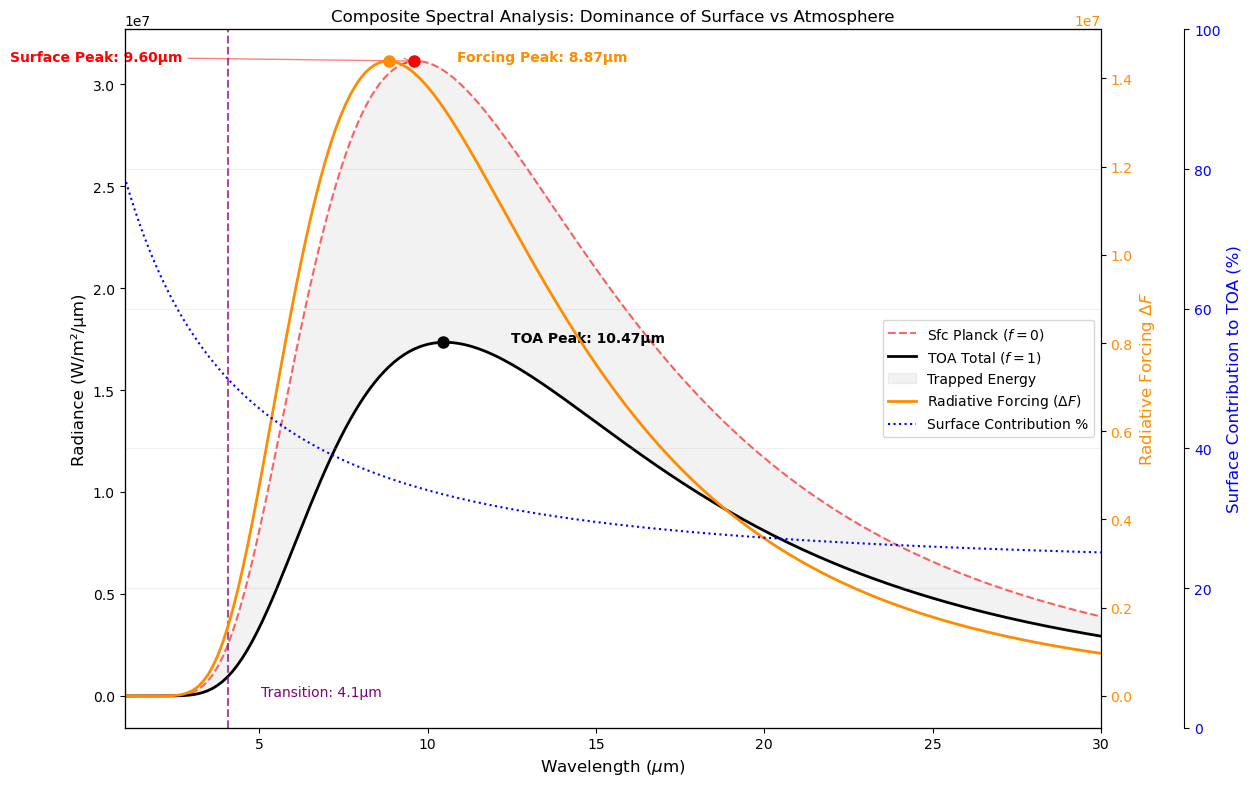

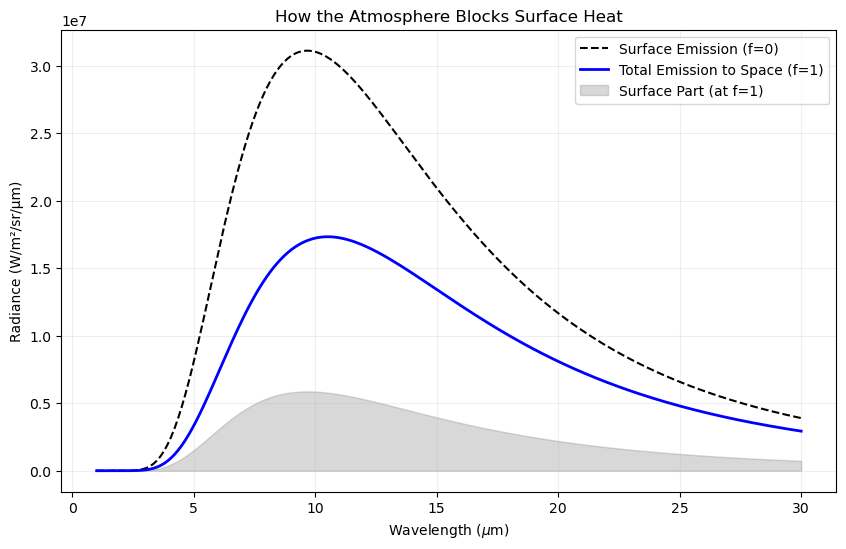

Successfully saved to: figures/Case_4_Spectral_Relationship_between_Energy_Trapping_and_Forcing.png


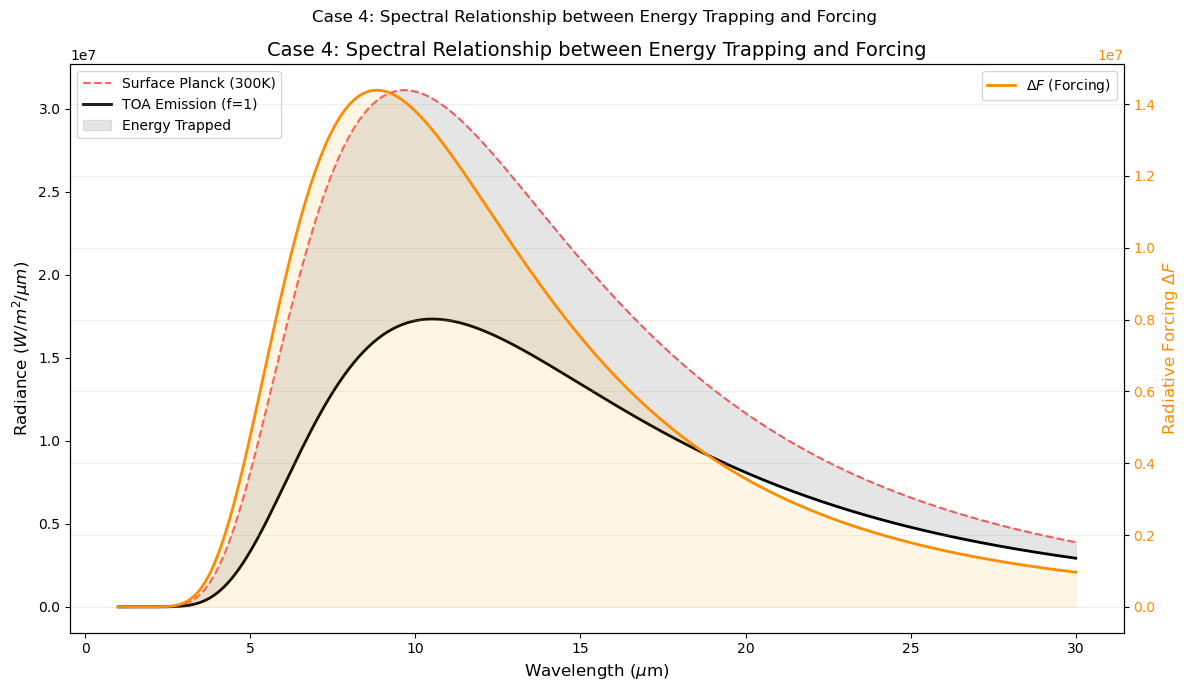

In [78]:
import numpy as np
import matplotlib.pyplot as plt


import os
import matplotlib.pyplot as plt

# 1. DO THIS AT THE VERY TOP OF YOUR SCRIPT
if not os.path.exists("figures"):
    os.makedirs("figures")

def save_fig():
    """Adapts your working folder logic with automatic naming."""
    # Get the title (handles both suptitles and standard titles)
    fig = plt.gcf()
    title = fig._suptitle.get_text() if fig._suptitle else plt.gca().get_title()
    
    # Clean the title to make it a safe filename
    clean_name = title.replace(" ", "_").replace(":", "").replace(".", "").replace("\n", "_")
    if not clean_name:
        clean_name = "untitled_plot"
    
    # Use your working path logic
    save_path = f"figures/{clean_name}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Successfully saved to: {save_path}")

# Constants
Ts = 300
r_val = 5/3
H_val = 8000
C_base = 1.25e-4
z_max = 100000
z = np.linspace(0, z_max, 5000)
f_fixed = 1

def get_planck_radiance(temp, wvl_nm):
    h, c, kb = 6.626e-34, 3.0e8, 1.38e-23
    lam = wvl_nm * 1e-9
    return (2 * h * c**2) / (lam**5 * np.expm1((h * c) / (lam * kb * temp)))

# Case 4 Temperature Profile
Gamma_d = 5 / 1000
Gamma_s = -2 / 1000
temp_z = np.zeros_like(z)
for i, height in enumerate(z):
    if height <= 20000:
        temp_z[i] = 300 - Gamma_d * height
    elif height <= 50000:
        temp_z[i] = 200 - Gamma_s * (height - 20000)
    else:
        temp_z[i] = 260

wavelengths_um = np.linspace(1, 30, 200) 
sfc_planck = []
toa_total_radiance = []
spectral_dF = []
sfc_contribution_pct = []
sfc_block_term = []
atm_emit_term = []

for lam in wavelengths_um:
    lam_nm = lam * 1000
    B_s = get_planck_radiance(Ts, lam_nm)
    B_atm_z = np.array([get_planck_radiance(t, lam_nm) for t in temp_z])
    
    tau_total = r_val * f_fixed * C_base * H_val
    tau_z = r_val * f_fixed * C_base * H_val * np.exp(-z/H_val)
    W_f = (r_val * f_fixed * C_base * np.exp(-z/H_val)) * np.exp(-tau_z)
    
    # Radiance terms at TOA
    radiance_sfc = np.pi * B_s * np.exp(-tau_total)
    radiance_atm = np.trapezoid(np.pi * B_atm_z * W_f, z)
    total_rad = radiance_sfc + radiance_atm
    
    # Forcing terms: dF = F(f) - F(0)
    # F(0) = -pi * B_s
    # F(f) = -(radiance_sfc + radiance_atm)
    # dF = pi * B_s - (radiance_sfc + radiance_atm)
    # dF = pi * B_s * (1 - exp(-tau_total)) - radiance_atm
    
    block_val = np.pi * B_s * (1 - np.exp(-tau_total))
    emit_val = radiance_atm
    forcing = block_val - emit_val
    
    sfc_planck.append(np.pi * B_s)
    toa_total_radiance.append(total_rad)
    spectral_dF.append(forcing)
    sfc_contribution_pct.append((radiance_sfc / total_rad) * 100)
    sfc_block_term.append(block_val)
    atm_emit_term.append(emit_val)

# Find transition wavelength where sfc contribution is < 50%
transition_idx = np.where(np.array(sfc_contribution_pct) < 50)[0]
transition_wave = wavelengths_um[transition_idx[0]] if len(transition_idx) > 0 else None

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 8))

# Axis 1: Radiance
ax1.plot(wavelengths_um, sfc_planck, color='red', linestyle='--', alpha=0.6, label='Sfc Planck ($f=0$)')
ax1.plot(wavelengths_um, toa_total_radiance, color='black', lw=2, label='TOA Total ($f=1$)')
ax1.fill_between(wavelengths_um, toa_total_radiance, sfc_planck, color='gray', alpha=0.1, label='Trapped Energy')
ax1.set_xlabel('Wavelength ($\mu$m)', fontsize=12)
ax1.set_ylabel('Radiance (W/m²/µm)', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xlim(1, 30)

# Axis 2: Forcing
ax2 = ax1.twinx()
ax2.plot(wavelengths_um, spectral_dF, color='darkorange', lw=2, label='Radiative Forcing ($\Delta F$)')
ax2.set_ylabel('Radiative Forcing $\Delta F$', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Axis 3: Surface Contribution %
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(wavelengths_um, sfc_contribution_pct, color='blue', linestyle=':', label='Surface Contribution %')
ax3.set_ylabel('Surface Contribution to TOA (%)', color='blue', fontsize=12)
ax3.tick_params(axis='y', labelcolor='blue')
ax3.set_ylim(0, 100)

if transition_wave:
    ax1.axvline(transition_wave, color='purple', linestyle='--', alpha=0.7)
    ax1.text(transition_wave+1, 1, f'Transition: {transition_wave:.1f}µm', color='purple', rotation=0)

plt.title('Composite Spectral Analysis: Dominance of Surface vs Atmosphere', fontsize=14)
# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines + lines2 + lines3, labels + labels2 + labels3, loc='center right')

plt.grid(True, alpha=0.2)
plt.tight_layout()

# 1. Surface Planck Peak 
max_sfc_idx = np.argmax(sfc_planck)
peak_sfc_wave = wavelengths_um[max_sfc_idx]
peak_sfc_val = sfc_planck[max_sfc_idx]

# 2. TOA Radiance Peak 
max_toa_idx = np.argmax(toa_total_radiance)
peak_toa_wave = wavelengths_um[max_toa_idx]
peak_toa_val = toa_total_radiance[max_toa_idx]

# 3. Forcing Peak 
max_df_idx = np.argmax(spectral_dF)
peak_df_wave = wavelengths_um[max_df_idx]
peak_df_val = spectral_dF[max_df_idx]

# --- ADDING LABELS TO THE GRAPH ---

# Surface Planck Peak (on ax1)
ax1.plot(peak_sfc_wave, peak_sfc_val, 'o', color='red', markersize=8)
ax1.annotate(f'Surface Peak: {peak_sfc_wave:.2f}µm', 
             xy=(peak_sfc_wave, peak_sfc_val), 
             xytext=(peak_sfc_wave-12, peak_sfc_val+0.2), # Positioned to the left
             color='red', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red', alpha=0.5))

# TOA Radiance Peak (on ax1)
ax1.plot(peak_toa_wave, peak_toa_val, 'o', color='black', markersize=8)
ax1.annotate(f'TOA Peak: {peak_toa_wave:.2f}µm', 
             xy=(peak_toa_wave, peak_toa_val), 
             xytext=(peak_toa_wave+2, peak_toa_val+0.3),
             color='black', fontweight='bold')

# Forcing Peak (on ax2)
ax2.plot(peak_df_wave, peak_df_val, 'o', color='darkorange', markersize=8)
ax2.annotate(f'Forcing Peak: {peak_df_wave:.2f}µm', 
             xy=(peak_df_wave, peak_df_val), 
             xytext=(peak_df_wave+2, peak_df_val),
             color='darkorange', fontweight='bold')
plt.title("Composite Spectral Analysis: Dominance of Surface vs Atmosphere")
save_fig()

print(f"Transition point (Surface < 50%): {transition_wave}")

# SPECTRAL RADIANCE COMPARISON

surface_radiance_space = [] # What makes it out from the ground
total_toa_radiance = []     # Ground + Atmosphere combined

for lam in wavelengths_um:
    lam_nm = lam * 1000
    B_s = get_planck_radiance(Ts, lam_nm)
    B_atm = np.array([get_planck_radiance(t, lam_nm) for t in temp_z])
    
    tau_total = r_val * f_fixed * C_base * H_val
    tau_z = r_val * f_fixed * C_base * H_val * np.exp(-z/H_val)
    W_f = (r_val * f_fixed * C_base * np.exp(-z/H_val)) * np.exp(-tau_z)
    
    # Term 1: Surface contribution 
    sfc_to_space = np.pi * B_s * np.exp(-tau_total)
    
    # Term 2: Atmosphere contribution 
    atm_to_space = np.trapezoid(np.pi * B_atm * W_f, z)
    
    surface_radiance_space.append(sfc_to_space)
    total_toa_radiance.append(sfc_to_space + atm_to_space)

plt.figure(figsize=(10, 6))
# 1. Theoretical Blackbody (what Earth emits if there were NO gas)
plt.plot(wavelengths_um, [np.pi * get_planck_radiance(Ts, l*1000) for l in wavelengths_um], 
         label='Surface Emission (f=0)', color='black', linestyle='--')

plt.plot(wavelengths_um, total_toa_radiance, label='Total Emission to Space (f=1)', color='blue', lw=2)

# 3. The portion of that which came from the ground
plt.fill_between(wavelengths_um, surface_radiance_space, color='gray', alpha=0.3, label='Surface Part (at f=1)')

plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Radiance (W/m²/sr/µm)')
plt.title('How the Atmosphere Blocks Surface Heat')
plt.legend()
plt.grid(True, alpha=0.2)
plt.title("How the Atmosphere Blocks Surface Heat")
save_fig()
plt.show()

# COMPOSITE PLOT: RADIANCE + FORCING

fig, ax1 = plt.subplots(figsize=(12, 7))

# --- AXIS 1: The Planck ---
ax1.plot(wavelengths_um, sfc_planck, label='Surface Planck (300K)', color='red', linestyle='--', alpha=0.6)
ax1.plot(wavelengths_um, toa_total_radiance, label='TOA Emission (f=1)', color='black', lw=2)
ax1.fill_between(wavelengths_um, toa_total_radiance, sfc_planck, color='gray', alpha=0.2, label='Energy Trapped')

ax1.set_xlabel('Wavelength ($\mu$m)', fontsize=12)
ax1.set_ylabel('Radiance ($W/m^2/µm$)', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.legend(loc='upper left')

# --- AXIS 2: The Resulting Forcing ---
# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx() 
ax2.plot(wavelengths_um, spectral_dF, color='darkorange', lw=2, label='$\Delta F$ (Forcing)')
ax2.fill_between(wavelengths_um, spectral_dF, color='orange', alpha=0.1)

ax2.set_ylabel('Radiative Forcing $\Delta F$', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='upper right')

plt.title('Case 4: Spectral Relationship between Energy Trapping and Forcing', fontsize=14)
plt.grid(True, alpha=0.2)
fig.tight_layout()
# --- At the end of your plotting code ---
plt.suptitle("Case 4: Spectral Relationship between Energy Trapping and Forcing") # Sets the filename
plt.tight_layout()

# 3. CALL THE FUNCTION
save_fig()
plt.show()



# AI Usage
## Tool used: Google Gemini
How it was used: wrote all initial Python code. The prompt was to incorperate my hand derived functions using the given extinction coeff. and concentration to first plot the optical depth, transmittance, and weighting function as functions of scaled concentration. Then to build upon that initial model to incorperate the derived radiative forcing equations for radiation leaving the TOA as a function of concentration and later as a polychromatic model for the student investigation. 

What I changed: I refined the code generated by Gemini to complete my objectives and generate representative figures. I verified the code's scientific merit and determined the best comparisons to make to elucidte the utility of the model.